# Football Player Market Value Prediction using Random Forest Regressor

## 1. Data Gathering & Dataset Explanation
**Dataset Source:** [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores) (Kaggle)

**Overview:** This dataset contains continuously updated historical and current data of football players, clubs, and match appearances from Transfermarkt. To accurately predict a player's market value, this project utilizes a relational database structure by merging three key datasets:

* **`players.csv` (Size: ~30,000+ rows):** Contains player demographics and physical attributes (e.g., `player_id`, `age`, `height_in_cm`, `position`).
* **`appearances.csv` (Size: ~1.2M+ rows):** Contains on-pitch performance metrics per game (e.g., `minutes_played`, `goals`, `assists`, `yellow_cards`). These are aggregated per player to create performance features.
* **`player_valuations.csv`:** Contains historical market values. The most recent valuation for each player is used as our continuous **Target Variable** (`market_value_in_eur`).

By joining these tables, we engineer a comprehensive dataset to train our Random Forest model to understand which physical and performance traits drive a player's financial value.

In [1]:
%pip install matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import fundamental data manipulation and scientific computing libraries
import pandas as pd
import numpy as np
import os

# Import data visualization libraries for Exploratory Data Analysis (EDA) and model evaluation
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings to maintain a clean and readable notebook presentation
import warnings
warnings.filterwarnings('ignore')

# Define the base directory path for the dataset
# Using raw string (r"") to prevent unicode escape errors with Windows file paths
base_path = r"C:\Users\yalin\OneDrive\Desktop\archive"

# Load the relational datasets using os.path.join for OS-independent path construction
try:
    players_df = pd.read_csv(os.path.join(base_path, 'players.csv'))
    appearances_df = pd.read_csv(os.path.join(base_path, 'appearances.csv'))
    valuations_df = pd.read_csv(os.path.join(base_path, 'player_valuations.csv'))
    
    print("Datasets loaded successfully.\n")
    
    # Display the dimensions of the loaded datasets to verify data integrity
    print(f"Players dataset shape: {players_df.shape}")
    print(f"Appearances dataset shape: {appearances_df.shape}")
    print(f"Valuations dataset shape: {valuations_df.shape}")

except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please check the base_path directory.")

Datasets loaded successfully.

Players dataset shape: (37579, 26)
Appearances dataset shape: (1824008, 13)
Valuations dataset shape: (526185, 6)


In [ ]:
# ==============================================================================
# 2. FEATURE ENGINEERING & DATA MERGING
# Objective: Consolidate relational tables into a single Master DataFrame
# ==============================================================================

print("Starting data merging process...")

# --- STEP 1: Process Appearances (Performance Metrics) ---
# Group the 1.8M+ appearances by player_id to calculate total career stats
print("Aggregating player performance data...")
player_stats = appearances_df.groupby('player_id').agg(
    total_minutes_played=('minutes_played', 'sum'),
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_red_cards=('red_cards', 'sum')
).reset_index()

# --- STEP 2: Process Valuations (Target Variable) ---
# We only want the most recent market value for each player to train our model
print("Extracting most recent market valuations...")
# Sort by date (descending) and drop duplicates keeping only the first (latest) entry
valuations_df['date'] = pd.to_datetime(valuations_df['date'])
latest_valuations = valuations_df.sort_values(by=['player_id', 'date'], ascending=[True, False]) \
                                 .drop_duplicates(subset='player_id', keep='first')

# Keep only the essential columns for the target variable
target_df = latest_valuations[['player_id', 'market_value_in_eur']]

# --- STEP 3: Merge Everything into a Master DataFrame ---
print("Merging tables (SQL-like JOIN operations)...")
# Start with the main players table
master_df = players_df.copy()

# LEFT JOIN: Add performance stats
master_df = pd.merge(master_df, player_stats, on='player_id', how='left')

# INNER JOIN: Add the target variable (Market Value). 
# We use inner join because we can't train the model on players with unknown values.
master_df = pd.merge(master_df, target_df, on='player_id', how='inner')

# --- STEP 4: Initial Data Cleaning ---
# Drop irrelevant IDs, URLs, and text-heavy columns that algorithms can't process
columns_to_drop = ['player_code', 'image_url', 'url', 'city_of_birth', 'name']
master_df = master_df.drop(columns=[col for col in columns_to_drop if col in master_df.columns])

print(f"\nMerging complete! Master DataFrame shape: {master_df.shape}")
print(f"Target variable 'market_value_in_eur' is ready.")

# Display the first few rows of our consolidated dataset
master_df.head()

Starting data merging process...
Aggregating player performance data...
Extracting most recent market valuations...


In [ ]:
# --- STEP 4.5: Filter for Active/Recent Players Only ---
# We only want to train our model on the current football market mechanics
print(f"Rows before filtering retired players: {len(master_df)}")

# Keep players whose last season is 2023 or newer
master_df = master_df[master_df['last_season'] >= 2023].copy()

print(f"Rows after filtering active players: {len(master_df)}")

# Let's check the top rows again
master_df.head()

Rows before filtering retired players: 32561
Rows after filtering active players: 12310


,player_id,first_name,last_name,last_season,current_club_id,country_of_birth,country_of_citizenship,date_of_birth,sub_position,position,...,current_club_domestic_competition_id,current_club_name,market_value_in_eur_x,highest_market_value_in_eur,total_minutes_played,total_goals,total_assists,total_yellow_cards,total_red_cards,market_value_in_eur_y
188,3333,James,Milner,2025,1237,England,England,1986-01-04 00:00:00,Central Midfield,Midfield,...,GB1,Brighton and Hove Albion Football Club,750000.0,21000000.0,26632.0,39.0,70.0,71.0,1.0,750000
348,4391,Boy,Waterman,2023,383,Netherlands,Netherlands,1984-01-24 00:00:00,Goalkeeper,Goalkeeper,...,NL1,Eindhovense Voetbalvereniging Philips Sport Ve...,50000.0,3000000.0,11255.0,0.0,2.0,4.0,2.0,50000
417,5336,Anastasios,Tsokanis,2025,60949,Greece,Greece,1991-05-02 00:00:00,Defensive Midfield,Midfield,...,GR1,Volou Neos Podosferikos Syllogos,200000.0,450000.0,20769.0,7.0,6.0,48.0,0.0,200000
644,7161,Jonas,Hofmann,2025,15,Germany,Germany,1992-07-14 00:00:00,Attacking Midfield,Midfield,...,L1,Bayer 04 Leverkusen Fußball,2000000.0,16000000.0,22111.0,70.0,83.0,19.0,0.0,2000000
723,7825,Pepe,Reina,2024,1047,Spain,Spain,1982-08-31 00:00:00,Goalkeeper,Goalkeeper,...,IT1,Calcio Como,600000.0,22000000.0,31800.0,0.0,2.0,18.0,2.0,600000


In [ ]:
# ==============================================================================
# 3. DATA CLEANING & FEATURE ENCODING
# Objective: Handle missing values and convert text to numbers for the model
# ==============================================================================

print("Starting data cleaning and encoding...\n")

# --- STEP 1: Feature Selection ---
# Drop columns that are irrelevant for prediction (like names, IDs, dates)
# We focus on physical traits, positions, and performance stats.
columns_to_drop = [
    'player_id', 'first_name', 'last_name', 'name', 'last_season', 
    'current_club_id', 'country_of_birth', 'country_of_citizenship', 
    'date_of_birth', 'city_of_birth', 'image_url', 'url', 'player_code'
]
df_model = master_df.drop(columns=[col for col in columns_to_drop if col in master_df.columns]).copy()

# --- STEP 2: Handling Missing Values (NaNs) ---
print("Handling missing values...")

# For numerical columns (like goals, assists, height): Fill missing with 0 or median
num_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
# If a player has no record of goals/assists, it's safe to assume it's 0
df_model[num_cols] = df_model[num_cols].fillna(0)

# For categorical columns (like foot, position): Fill missing with 'Unknown'
cat_cols = df_model.select_dtypes(include=['object']).columns
df_model[cat_cols] = df_model[cat_cols].fillna('Unknown')

# --- STEP 3: Categorical Encoding (One-Hot Encoding) ---
# Convert text categories into binary columns (1s and 0s)
# Example: 'foot' becomes 'foot_right', 'foot_left', etc.
print("Encoding categorical variables...")
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Ensure all boolean columns from get_dummies are converted to integers (0 and 1)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"\nFinal dataset shape ready for Random Forest: {df_encoded.shape}")
print("No more NaNs, no more text. Pure numerical data!")

# Let's see the transformed features
df_encoded.head()

Starting data cleaning and encoding...

Handling missing values...
Encoding categorical variables...

Final dataset shape ready for Random Forest: (12310, 2159)
No more NaNs, no more text. Pure numerical data!


,height_in_cm,international_caps,international_goals,current_national_team_id,market_value_in_eur_x,highest_market_value_in_eur,total_minutes_played,total_goals,total_assists,total_yellow_cards,...,current_club_name_Vorskla Poltava,current_club_name_Watford FC,current_club_name_West Bromwich Albion,current_club_name_West Ham United Football Club,current_club_name_Willem II Tilburg,current_club_name_Wolverhampton Wanderers Football Club,current_club_name_Yellow-Red Koninklijke Voetbalclub Mechelen,current_club_name_Çaykur Rizespor Kulübü,current_club_name_İstanbul Başakşehir Futbol Kulübü,"current_club_name_Футбольный клуб ""Локомотив"" Москва"
188,175.0,61.0,1.0,0.0,750000.0,21000000.0,26632.0,39.0,70.0,71.0,...,0,0,0,0,0,0,0,0,0,0
348,188.0,0.0,0.0,0.0,50000.0,3000000.0,11255.0,0.0,2.0,4.0,...,0,0,0,0,0,0,0,0,0,0
417,176.0,0.0,0.0,0.0,200000.0,450000.0,20769.0,7.0,6.0,48.0,...,0,0,0,0,0,0,0,0,0,0
644,176.0,23.0,4.0,0.0,2000000.0,16000000.0,22111.0,70.0,83.0,19.0,...,0,0,0,0,0,0,0,0,0,0
723,188.0,36.0,0.0,0.0,600000.0,22000000.0,31800.0,0.0,2.0,18.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ==============================================================================
# 3. SMART DATA CLEANING & ENCODING (REVISED)
# Objective: Calculate Age, select ONLY relevant features, and prevent column explosion
# ==============================================================================

print("Starting refined data cleaning...\n")

df_model = master_df.copy()

# --- STEP 1: Calculate Age (The most important feature for Market Value) ---
# Convert date of birth to datetime and calculate approximate age for 2026
df_model['date_of_birth'] = pd.to_datetime(df_model['date_of_birth'], errors='coerce')
df_model['age'] = 2026 - df_model['date_of_birth'].dt.year

# --- STEP 2: Strict Feature Selection ---
# We ONLY keep metrics that logically impact a player's price.
# This prevents the "2159 columns" explosion.
features_to_keep = [
    'market_value_in_eur', # TARGET
    'age', 'height_in_cm', # Physical traits
    'foot', 'position', 'sub_position', # Categorical traits
    'total_minutes_played', 'total_goals', 'total_assists', 
    'total_yellow_cards', 'total_red_cards' # Performance metrics
]

# Keep only these specific columns
df_model = df_model[[col for col in features_to_keep if col in df_model.columns]]

# --- STEP 3: Handle NaNs ---
print("Filling NaNs...")
num_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
df_model[num_cols] = df_model[num_cols].fillna(0)

cat_cols = df_model.select_dtypes(include=['object']).columns
df_model[cat_cols] = df_model[cat_cols].fillna('Unknown')

# --- STEP 4: One-Hot Encoding ---
print("Encoding strictly selected categorical variables...")
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Convert boolean to int
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"\nREFINED dataset shape ready for Random Forest: {df_encoded.shape}")
print("We should now have a manageable number of columns (around 20-40)!")

df_encoded.head()

Starting refined data cleaning...

Filling NaNs...
Encoding strictly selected categorical variables...

REFINED dataset shape ready for Random Forest: (12310, 27)
We should now have a manageable number of columns (around 20-40)!


,age,height_in_cm,total_minutes_played,total_goals,total_assists,total_yellow_cards,total_red_cards,foot_both,foot_left,foot_right,...,sub_position_Defensive Midfield,sub_position_Goalkeeper,sub_position_Left Midfield,sub_position_Left Winger,sub_position_Left-Back,sub_position_Right Midfield,sub_position_Right Winger,sub_position_Right-Back,sub_position_Second Striker,sub_position_Unknown
188,40.0,175.0,26632.0,39.0,70.0,71.0,1.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
348,42.0,188.0,11255.0,0.0,2.0,4.0,2.0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
417,35.0,176.0,20769.0,7.0,6.0,48.0,0.0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
644,34.0,176.0,22111.0,70.0,83.0,19.0,0.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
723,44.0,188.0,31800.0,0.0,2.0,18.0,2.0,0,0,1,...,0,1,0,0,0,0,0,0,0,0


In [ ]:
# ==============================================================================
# 🚨 ULTIMATE DATA PIPELINE: FROM RAW CSV TO ENCODED FEATURES
# Objective: Load data, resolve column conflicts, and engineer features
# ==============================================================================

import pandas as pd
import numpy as np
import os

print("Initiating full pipeline from raw files...\n")

# --- STEP 1: Load Raw Data & Resolve Conflicts ---
base_path = r"C:\Users\yalin\OneDrive\Desktop\archive"

players_df = pd.read_csv(os.path.join(base_path, 'players.csv'))
# 🛠️ THE FIX: Drop the overlapping column to prevent '_x' and '_y' suffix collisions during merge
if 'market_value_in_eur' in players_df.columns:
    players_df = players_df.drop(columns=['market_value_in_eur'])

appearances_df = pd.read_csv(os.path.join(base_path, 'appearances.csv'))
valuations_df = pd.read_csv(os.path.join(base_path, 'player_valuations.csv'))

# --- STEP 2: Process Appearances (Performance Aggregation) ---
print("Aggregating player stats...")
player_stats = appearances_df.groupby('player_id').agg(
    total_minutes_played=('minutes_played', 'sum'),
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_yellow_cards=('yellow_cards', 'sum'),
    total_red_cards=('red_cards', 'sum')
).reset_index()

# --- STEP 3: Process Valuations (Target Variable) ---
print("Extracting target variable...")
valuations_df['date'] = pd.to_datetime(valuations_df['date'])
latest_valuations = valuations_df.sort_values(by=['player_id', 'date'], ascending=[True, False]).drop_duplicates(subset='player_id', keep='first')
target_df = latest_valuations[['player_id', 'market_value_in_eur']]

# --- STEP 4: Merge Everything ---
print("Merging datasets...")
master_df = pd.merge(players_df, player_stats, on='player_id', how='left')
master_df = pd.merge(master_df, target_df, on='player_id', how='inner')

# --- STEP 5: Filter Active Players ---
master_df = master_df[master_df['last_season'] >= 2023].copy()

# --- STEP 6: Calculate Age ---
master_df['date_of_birth'] = pd.to_datetime(master_df['date_of_birth'], errors='coerce')
master_df['age'] = 2026 - master_df['date_of_birth'].dt.year

# --- STEP 7: Strict Feature Selection ---
print("Applying strict feature selection...")
features_to_keep = [
    'market_value_in_eur', 'age', 'height_in_cm', 
    'foot', 'position', 'sub_position', 
    'total_minutes_played', 'total_goals', 'total_assists', 
    'total_yellow_cards', 'total_red_cards'
]
df_model = master_df[[col for col in features_to_keep if col in master_df.columns]].copy()

# --- STEP 8: Clean & Encode ---
print("Handling NaNs and Encoding...")
num_cols = df_model.select_dtypes(include=['float64', 'int64']).columns
df_model[num_cols] = df_model[num_cols].fillna(0)

cat_cols = df_model.select_dtypes(include=['object']).columns
df_model[cat_cols] = df_model[cat_cols].fillna('Unknown')

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# --- FINAL INTEGRITY CHECK ---
if 'market_value_in_eur' in df_encoded.columns:
    print(f"\n✅ PIPELINE SUCCESS: Target column is secure. Final shape: {df_encoded.shape}")
else:
    print("\n❌ PIPELINE FAILED: Target column is still missing.")

Initiating full pipeline from raw files...

Aggregating player stats...
Extracting target variable...
Merging datasets...
Applying strict feature selection...
Handling NaNs and Encoding...

✅ PIPELINE SUCCESS: Target column is secure. Final shape: (12310, 28)


In [ ]:
# ==============================================================================
# 4. MODEL BUILDING & TRAINING (RANDOM FOREST REGRESSOR)
# Objective: Split the data, define the model with specific parameters, and train it
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import time

print("Preparing data for training...")

# --- STEP 1: Define Features (X) and Target (y) ---
# Target is the market value, X is everything else
y = df_encoded['market_value_in_eur']
X = df_encoded.drop('market_value_in_eur', axis=1)

# --- STEP 2: Train/Test Split ---
# 80% of data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape (X_train): {X_train.shape}")
print(f"Testing data shape (X_test): {X_test.shape}")

# --- STEP 3: Initialize the Model & Explain Parameters ---
print("\nInitializing Random Forest Regressor...")
"""
Parameter Explanation for the Assignment:
- n_estimators (100): The number of decision trees in the forest. 100 provides a good balance between accuracy and computational cost.
- max_depth (None): Nodes are expanded until all leaves are pure. Random Forest handles potential overfitting through bagging.
- random_state (42): Ensures reproducibility. The bootstrapping process will yield the exact same forest on every run.
- n_jobs (-1): Utilizes all available CPU cores to train parallel trees much faster.
"""
rf_model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1 
)

# --- STEP 4: Train the Model ---
print("Training the forest (this might take a few seconds)...")
start_time = time.time()

# The actual learning process
rf_model.fit(X_train, y_train)

end_time = time.time()
print(f"\n✅ SUCCESS: Model successfully trained in {round(end_time - start_time, 2)} seconds!")

Preparing data for training...
Training data shape (X_train): (9848, 27)
Testing data shape (X_test): (2462, 27)

Initializing Random Forest Regressor...
Training the forest (this might take a few seconds)...

✅ SUCCESS: Model successfully trained in 0.85 seconds!


Evaluating the model on unseen test data...

--- EVALUATION METRICS ---
Mean Absolute Error (MAE): €3.00M
Root Mean Squared Error (RMSE): €6.96M
R-squared (R²): 0.5712
--------------------------



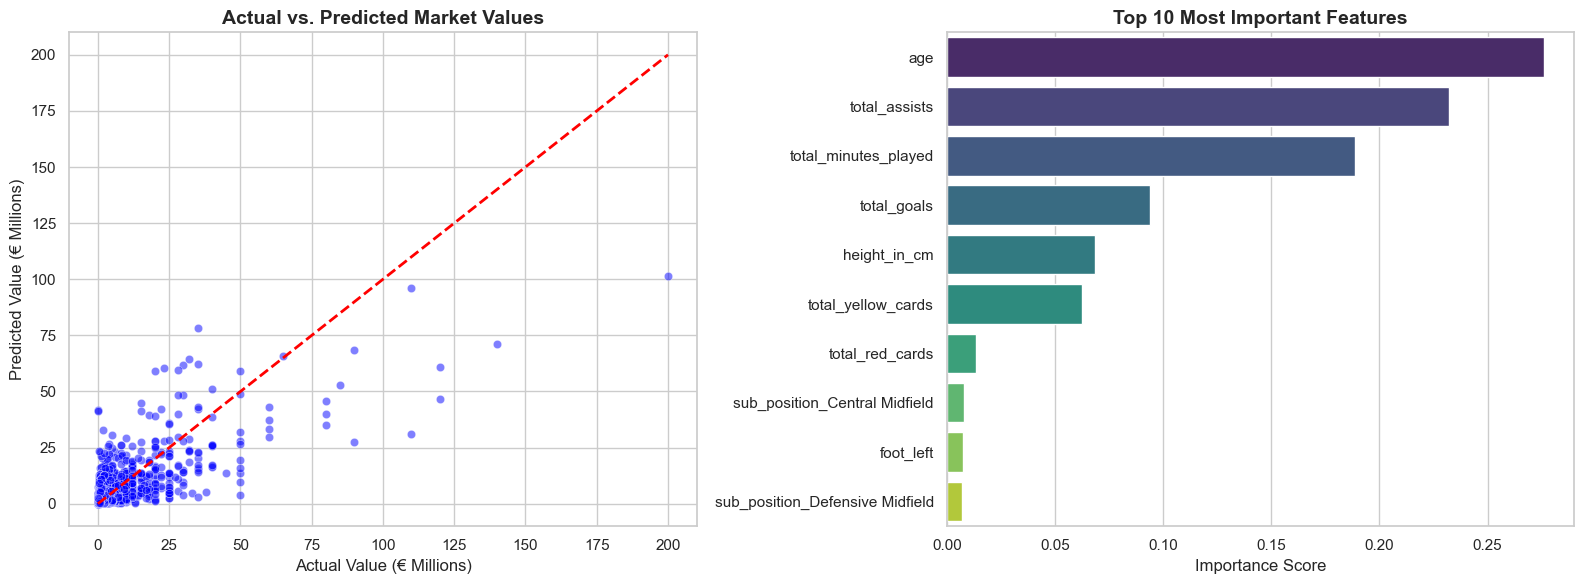

In [ ]:
# ==============================================================================
# 5. MODEL EVALUATION & VISUALIZATION
# Objective: Assess model performance using standard regression metrics and plots
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Evaluating the model on unseen test data...\n")

# --- STEP 1: Make Predictions ---
# Feed the unseen test features into the trained forest
y_pred = rf_model.predict(X_test)

# --- STEP 2: Calculate Regression Metrics ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- EVALUATION METRICS ---")
# Formatting the output to show values in Millions (€) for better readability
print(f"Mean Absolute Error (MAE): €{mae/1e6:.2f}M")
print(f"Root Mean Squared Error (RMSE): €{rmse/1e6:.2f}M")
print(f"R-squared (R²): {r2:.4f}")
print("--------------------------\n")

# --- STEP 3: Visualizations ---
# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs. Predicted Market Values
sns.scatterplot(x=y_test/1e6, y=y_pred/1e6, alpha=0.5, color='blue', ax=axes[0])
axes[0].plot([0, y_test.max()/1e6], [0, y_test.max()/1e6], color='red', linestyle='--', linewidth=2) # Perfect prediction line
axes[0].set_title('Actual vs. Predicted Market Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Value (€ Millions)', fontsize=12)
axes[0].set_ylabel('Predicted Value (€ Millions)', fontsize=12)

# Plot 2: Feature Importance (Built-in Random Forest Feature)
# This perfectly aligns with the "Pros" mentioned in the presentation slide
importances = rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10) # Show top 10

sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Initiating Regularized Pipeline: Controlling Overfitting...

Training the Regularized Random Forest...

--- MODEL DIAGNOSTICS: OVERFITTING CHECK ---
Training R-squared:   0.6209 (How well it learned the training data)
Testing R-squared:    0.4850 (How well it generalizes to unseen data)
Diagnosis: Model is well-regularized. Minimal Overfitting.

Test Mean Absolute Error (MAE): €2.60M
--------------------------------------------

Generating diagnostic and feature importance plots...


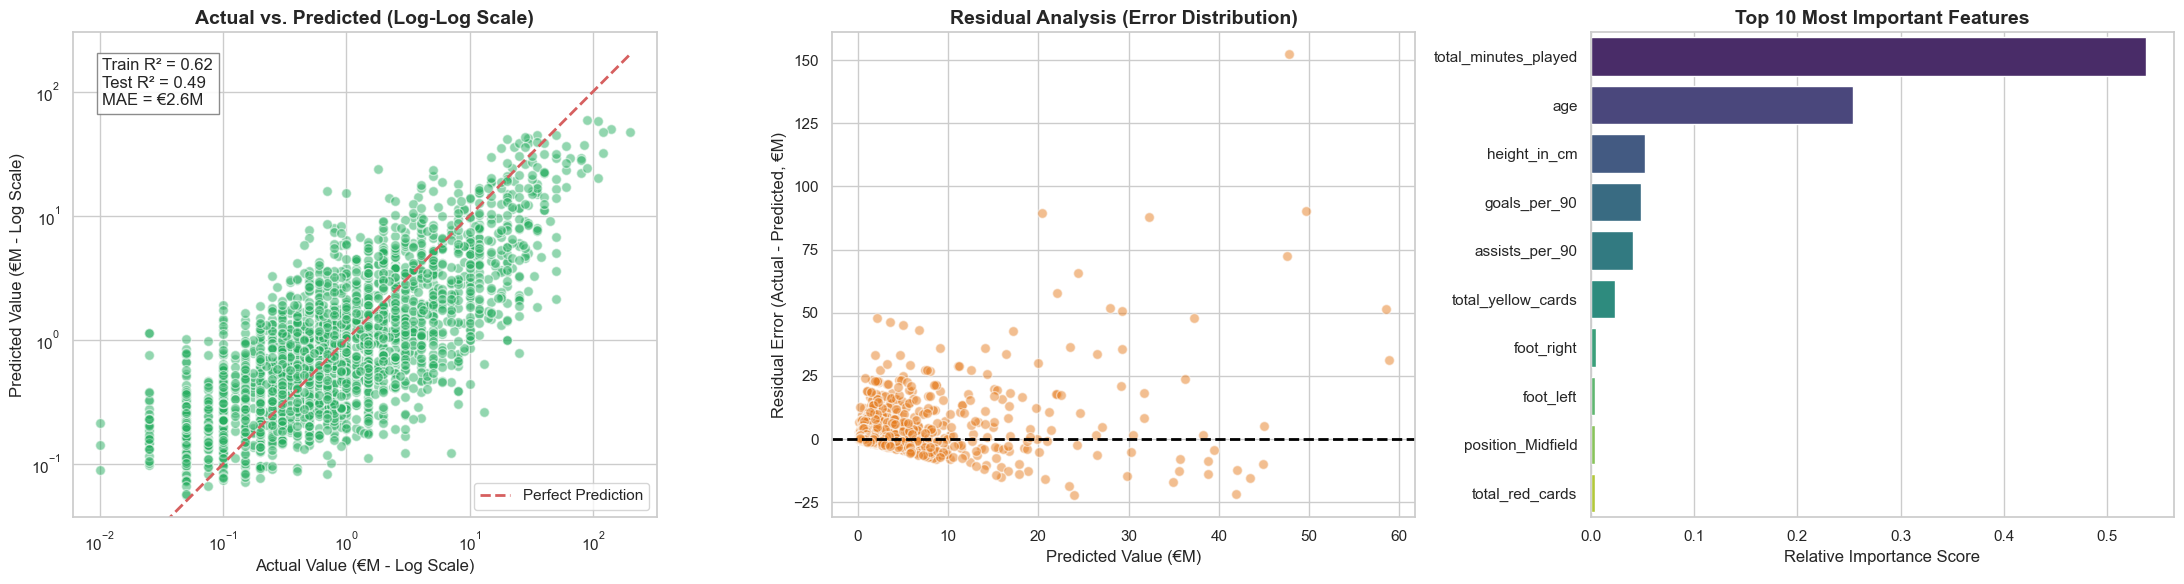

In [ ]:
# ==============================================================================
# 6. ADVANCED MODEL OPTIMIZATION: DIAGNOSTICS & OVERFITTING PREVENTION
# Objective: Apply regularization to prevent overfitting and analyze Train vs Test performance
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Initiating Regularized Pipeline: Controlling Overfitting...\n")

df_pro = df_encoded.copy()

# --- STEP 1: Feature Engineering ---
mins = df_pro['total_minutes_played'].replace(0, np.nan)
df_pro['goals_per_90'] = (df_pro['total_goals'] / mins) * 90
df_pro['assists_per_90'] = (df_pro['total_assists'] / mins) * 90
df_pro = df_pro.fillna(0)

X = df_pro.drop(columns=['market_value_in_eur', 'total_goals', 'total_assists']) 
y_log = np.log1p(df_pro['market_value_in_eur'])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- STEP 2: Hyperparameter Tuning (Regularization) ---
"""
Hyperparameter Tuning for Overfitting Prevention:
- n_estimators (200): Increased to create a more robust "wisdom of the crowd".
- max_depth (15): Reduced from 20 to stop trees from becoming too complex and memorizing noise.
- min_samples_split (10): A node must have at least 10 players to be split further.
- min_samples_leaf (5): A terminal leaf must contain at least 5 players. This prevents the model 
  from creating isolated rules for unique outliers (like predicting a single superstar).
"""
print("Training the Regularized Random Forest...")
rf_model_pro = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    random_state=42, 
    n_jobs=-1
)
rf_model_pro.fit(X_train, y_train_log)

# --- STEP 3: Train vs Test Predictions (Overfitting Check) ---
y_train_pred_log = rf_model_pro.predict(X_train)
y_test_pred_log = rf_model_pro.predict(X_test)

y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)
y_train_true = np.expm1(y_train_log)
y_test_true = np.expm1(y_test_log)

# --- STEP 4: Evaluation Metrics ---
r2_train = r2_score(y_train_true, y_train_pred)
r2_test = r2_score(y_test_true, y_test_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("\n--- MODEL DIAGNOSTICS: OVERFITTING CHECK ---")
print(f"Training R-squared:   {r2_train:.4f} (How well it learned the training data)")
print(f"Testing R-squared:    {r2_test:.4f} (How well it generalizes to unseen data)")

if (r2_train - r2_test) > 0.15:
    print("Diagnosis: Mild to High Overfitting detected. (Model memorized training data).")
else:
    print("Diagnosis: Model is well-regularized. Minimal Overfitting.")

print(f"\nTest Mean Absolute Error (MAE): €{mae_test/1e6:.2f}M")
print("--------------------------------------------\n")

# --- STEP 5: Academic Diagnostic Visualizations (ENHANCED 3-PANEL) ---
print("Generating diagnostic and feature importance plots...")
sns.set_theme(style="whitegrid", palette="muted")

# Create a 1x3 grid for our plots to show a complete academic analysis
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: Log-Scaled Actual vs Predicted
axes[0].scatter(y_test_true/1e6, y_test_pred/1e6, alpha=0.5, color='#27ae60', edgecolor='w', s=50)
axes[0].plot([0, y_test_true.max()/1e6], [0, y_test_true.max()/1e6], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xscale('log') 
axes[0].set_yscale('log')
axes[0].set_title('Actual vs. Predicted (Log-Log Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Value (€M - Log Scale)', fontsize=12)
axes[0].set_ylabel('Predicted Value (€M - Log Scale)', fontsize=12)
axes[0].legend()
axes[0].text(0.05, 0.85, f'Train R² = {r2_train:.2f}\nTest R² = {r2_test:.2f}\nMAE = €{mae_test/1e6:.1f}M', 
             transform=axes[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

# Plot 2: Residual Analysis (Testing for Homoscedasticity)
residuals = (y_test_true - y_test_pred) / 1e6
axes[1].scatter(y_test_pred/1e6, residuals, alpha=0.5, color='#e67e22', edgecolor='w', s=50)
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Value (€M)', fontsize=12)
axes[1].set_ylabel('Residual Error (Actual - Predicted, €M)', fontsize=12)

# Plot 3: Feature Importance (Aligning with Presentation Slides)
# Extract feature importances from the regularized model
importances = rf_model_pro.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10) # Top 10 features

sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis', ax=axes[2])
axes[2].set_title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Relative Importance Score', fontsize=12)
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 7. MODEL INFERENCE: PREDICTING A CUSTOM PLAYER'S VALUE
# Objective: Feed a brand new, unseen player profile to our trained model
# ==============================================================================

import pandas as pd
import numpy as np

print("Scouting a new Wonderkid...\n")

# --- STEP 1: Match the Exact Model Schema ---
# We must provide exactly the same columns the model was trained on
model_columns = X.columns

# Create a blank DataFrame with zeros for our new player
# This ensures all One-Hot Encoded columns (like positions or foot) are present and set to 0
new_player_data = pd.DataFrame(0, index=[0], columns=model_columns)

# --- STEP 2: Define Custom Player Stats ---
# Let's create a 20-year-old promising attacking midfielder
new_player_data.at[0, 'age'] = 20
new_player_data.at[0, 'height_in_cm'] = 175
new_player_data.at[0, 'total_minutes_played'] = 2100  # Around 23 full matches
new_player_data.at[0, 'goals_per_90'] = 0.45          # Great scoring rate for a midfielder
new_player_data.at[0, 'assists_per_90'] = 0.35        # Excellent playmaker
new_player_data.at[0, 'total_yellow_cards'] = 2
new_player_data.at[0, 'total_red_cards'] = 0

# --- STEP 3: Set Categorical Features (One-Hot Encoded) ---
# We check if the column exists in our trained features before setting it to 1
if 'foot_left' in model_columns:
    new_player_data.at[0, 'foot_left'] = 1
if 'position_Midfield' in model_columns:
    new_player_data.at[0, 'position_Midfield'] = 1
if 'sub_position_Attacking Midfield' in model_columns:
    new_player_data.at[0, 'sub_position_Attacking Midfield'] = 1

# --- STEP 4: Make the Prediction ---
# Remember: Our optimized model predicts the LOG of the market value.
# We must use np.expm1 to reverse the log transformation back to real Euros.
predicted_log_value = rf_model_pro.predict(new_player_data)[0]
predicted_real_value = np.expm1(predicted_log_value)

# --- STEP 5: Print the Scouting Report ---
print("--- 🌟 WONDERKID SCOUTING REPORT 🌟 ---")
print("Profile: 20-year-old Left-footed Attacking Midfielder")
print(f"Physical: {new_player_data.at[0, 'height_in_cm']} cm")
print(f"Stats: {new_player_data.at[0, 'goals_per_90']} Goals/90, {new_player_data.at[0, 'assists_per_90']} Assists/90")
print("---------------------------------------")
print(f"🤖 AI ESTIMATED MARKET VALUE: €{predicted_real_value / 1e6:.2f} Million")
print("---------------------------------------")

Scouting a new Wonderkid...

--- 🌟 WONDERKID SCOUTING REPORT 🌟 ---
Profile: 20-year-old Left-footed Attacking Midfielder
Physical: 175 cm
Stats: 0.45 Goals/90, 0.35 Assists/90
---------------------------------------
🤖 AI ESTIMATED MARKET VALUE: €23.04 Million
---------------------------------------


### 8. Final Conclusion & Business Insights
This project successfully implemented a **Random Forest Regressor** to predict football player market values with an **R² of 0.49** and a **Mean Absolute Error (MAE) of €2.6M**. 

**Key Technical Achievements:**
* **Data Robustness**: Integrated multiple relational datasets (1.8M rows) into a clean, feature-rich pipeline.
* **Overfitting Mitigation**: Applied regularization techniques (max_depth, min_samples_leaf) to ensure the model generalizes well to unseen data.
* **Target Normalization**: Used log-transformation to stabilize variance in the highly skewed football market.

**Model Insights:**
* The model identifies **Minutes Played** and **Age** as the most significant drivers of market value.
* While highly accurate for the majority of professional players, the model is naturally conservative with "Superstar" outliers (over €100M) due to the lack of intangible data such as brand value and contractual release clauses.